# Import our functions to test

In [1]:
%load_ext autoreload
%autoreload 2

import diffolars.diff as dd
from diffolars.cli import diff_cli
from diffolars.demo import get_df_pair
import polars as pl

# Testing the core CLI usage here:

In [2]:
# Example Usage:

# GENERATE TEST DATA PAIR WITH 100 ROWS and 32 COLUMNS

dfs = get_df_pair(100, 32, n_new_cols=5, n_new_rows=5, coverage=0.10)
o = dfs['original']
m = dfs['mutated']

# WRITE TEST DATA TO PARQUET

o.write_parquet('o.parquet')
m.write_parquet('m.parquet')


# CALL CLI TOOL TARGETING THE LOCAL DATA PAIR
diff_cli(
    ['--scan', 
     '--write',
     '--prev-load', 'o.parquet', 
     '--latest-load', 'm.parquet', 
     '--id-col', 'record_id',
     '--top-n', 10
     ],
    standalone_mode=False,
)

# Check output printed in this notebook.

Generating initial dataset with 100 rows and 32 columns.
Generated mutated dataset.
Found 0 rows unique to the current (original) table.
Found 5 rows unique to the next (latest) table.


##################################################
DIFF ACTIVITY LOG RECORD

shape: (1, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ date_pruned  ┆ cols_only_i ┆ num_rows_on ┆ cols_only_i ┆ num_rows_on ┆ current_loa ┆ latest_load │
│ ---          ┆ n_prev_load ┆ ly_in_prev_ ┆ n_latest_lo ┆ ly_in_lates ┆ d_table     ┆ _table      │
│ datetime[μs] ┆ ---         ┆ load        ┆ ad          ┆ t_load      ┆ ---         ┆ ---         │
│              ┆ str         ┆ ---         ┆ ---         ┆ ---         ┆ str         ┆ str         │
│              ┆             ┆ i64         ┆ str         ┆ i64         ┆             ┆             │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 2026-07-04   

C:\Users\kenne\Documents\CSE550\GitLab\diffolars\src\diffolars\diff.py:245: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  return input.columns


# Testing component functions

In [3]:
prune_record = dd.report_prune(o, m)
pruned_df = dd.pruned_rows(o, m)
result_df = dd.bitdiff(o, m)

print("\n")
print(pl.DataFrame(prune_record))
print(pruned_df)
result_df


Found 0 rows unique to the current (original) table.
Found 5 rows unique to the next (latest) table.


shape: (1, 5)
┌───────────────┬────────────────────┬────────────────────┬────────────────────┬───────────────────┐
│ date_pruned   ┆ cols_only_in_prev_ ┆ num_rows_only_in_p ┆ cols_only_in_lates ┆ num_rows_only_in_ │
│ ---           ┆ load               ┆ rev_load           ┆ t_load             ┆ latest_load       │
│ datetime[μs]  ┆ ---                ┆ ---                ┆ ---                ┆ ---               │
│               ┆ str                ┆ i64                ┆ str                ┆ i64               │
╞═══════════════╪════════════════════╪════════════════════╪════════════════════╪═══════════════════╡
│ 2026-07-04    ┆ No exclusives      ┆ 0                  ┆ col_32_int ,       ┆ 5                 │
│ 12:09:00      ┆                    ┆                    ┆ col_34_float , co… ┆                   │
└───────────────┴────────────────────┴────────────────────┴────────────────

record_id,diff_bitarray
str,u64
"""4b18836f-a86a-4c08-bce5-46d350…",4293918719
"""d03046b2-4a26-4e3e-aea3-10eadb…",4294375415
"""7e47ce37-22a2-40bc-867d-3abe1f…",4294897375
"""81e59e53-5d23-438b-baeb-d193e6…",4294967295
"""35ef7b4a-c5fe-416f-b592-946c40…",4294967295
…,…
"""a1b1e1ea-9695-4b33-859a-f82792…",4263509915
"""7f55885e-87a6-4328-987e-a35dd9…",4294967295
"""21a29c64-1f49-41bc-b06d-40bbd6…",4294967007


In [4]:
# Now test the bitdiff_summary
summarydf = dd.bitdiff_summary(
    a = r'data\o-m\2026-07-04\o.parquet',
    b = r'data\o-m\2026-07-04\m.parquet',
    bitdiff_df = r'data\o-m\2026-07-04\diff_bitarray_results.parquet'
)
summarydf.write_csv('check_summarydf.csv')
summarydf

Reading bitdiff results from parquet path...
2026-07-04 12:09:00


date_diffed,column_name,cnt_not_modified,cnt_modified
datetime[μs],str,i64,i64
2026-07-04 12:09:00,"""col_0_int""",98,2
2026-07-04 12:09:00,"""col_1_str""",93,7
2026-07-04 12:09:00,"""col_2_float""",92,8
2026-07-04 12:09:00,"""col_3_datetime""",87,13
2026-07-04 12:09:00,"""col_4_int""",88,12
…,…,…,…
2026-07-04 12:09:00,"""col_27_datetime""",92,8
2026-07-04 12:09:00,"""col_28_int""",89,11
2026-07-04 12:09:00,"""col_29_str""",91,9


Reading bitdiff results from parquet path...


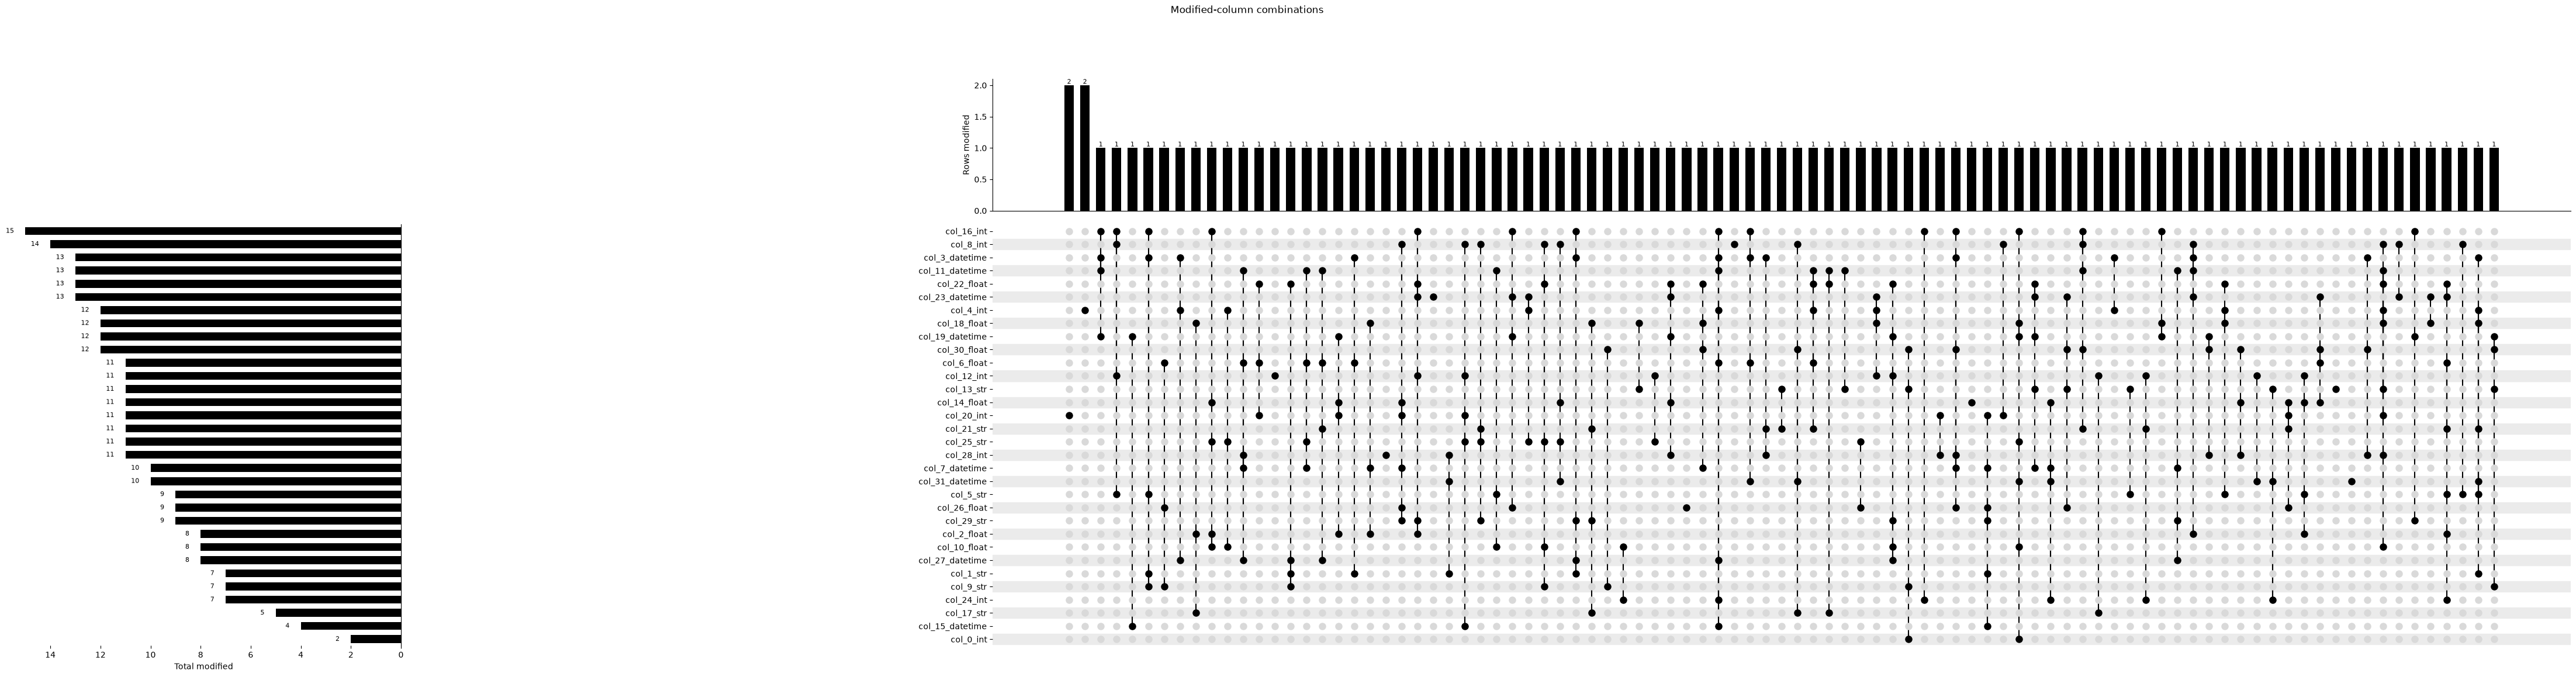

In [5]:
# Test the plotting function
dd.bitdiff_plot(
    a = r'data\o-m\2026-07-04\o.parquet',
    b = r'data\o-m\2026-07-04\m.parquet',
    bitdiff_df = r'data\o-m\2026-07-04\diff_bitarray_results.parquet',
    top_n = 100
)

# Checking other functionalities by themselves...

In [6]:
# Here, we get the core tables:
oc, mc = dd.get_core(o, m)
print(oc.head(5))
print(mc.head(5))

shape: (5, 33)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ record_id ┆ col_0_int ┆ col_1_str ┆ col_2_flo ┆ … ┆ col_28_in ┆ col_29_st ┆ col_30_fl ┆ col_31_d │
│ _A        ┆ _A        ┆ _A        ┆ at_A      ┆   ┆ t_A       ┆ r_A       ┆ oat_A     ┆ atetime_ │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ A        │
│ str       ┆ i64       ┆ str       ┆ f64       ┆   ┆ i64       ┆ str       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ datetime │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ [μs]     │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 4b18836f- ┆ -232792   ┆ tPuQMGGOL ┆ -702797.1 ┆ … ┆ -106194   ┆ qMDweQkUI ┆ 414216.39 ┆ 2000-06- │
│ a86a-4c08 ┆           ┆ K         ┆ 73886     ┆   ┆           ┆ c         

In [7]:
dd.column_intercept(o, m)

{'col_0_int',
 'col_10_float',
 'col_11_datetime',
 'col_12_int',
 'col_13_str',
 'col_14_float',
 'col_15_datetime',
 'col_16_int',
 'col_17_str',
 'col_18_float',
 'col_19_datetime',
 'col_1_str',
 'col_20_int',
 'col_21_str',
 'col_22_float',
 'col_23_datetime',
 'col_24_int',
 'col_25_str',
 'col_26_float',
 'col_27_datetime',
 'col_28_int',
 'col_29_str',
 'col_2_float',
 'col_30_float',
 'col_31_datetime',
 'col_3_datetime',
 'col_4_int',
 'col_5_str',
 'col_6_float',
 'col_7_datetime',
 'col_8_int',
 'col_9_str',
 'record_id'}

In [8]:
dd.report_prune(o, m)

{'date_pruned': datetime.datetime(2026, 7, 4, 12, 9),
 'cols_only_in_prev_load': 'No exclusives',
 'num_rows_only_in_prev_load': 0,
 'cols_only_in_latest_load': 'col_32_int , col_34_float , col_35_datetime , col_33_str , col_36_int',
 'num_rows_only_in_latest_load': 5}

In [9]:
dd.pruned_rows(o, m)

Found 0 rows unique to the current (original) table.
Found 5 rows unique to the next (latest) table.


date_pruned,source_dataload,record_id
datetime[μs],str,str
2026-07-04 12:09:00,"""latest load""","""77cd5a42-8821-4ac1-b1b9-4026f6…"
2026-07-04 12:09:00,"""latest load""","""8301f666-2e1f-4b8c-b292-620e85…"
2026-07-04 12:09:00,"""latest load""","""3c87763d-a0ad-4606-a8a9-2df96b…"
2026-07-04 12:09:00,"""latest load""","""6d542b8c-1a49-456a-8b95-1432de…"
2026-07-04 12:09:00,"""latest load""","""be7c116e-4434-41b5-9686-ae0418…"


In [10]:
csd=dd.column_symmetric_diff(o, m)
csd



{'prev_load': set(),
 'latest_load': {'col_32_int',
  'col_33_str',
  'col_34_float',
  'col_35_datetime',
  'col_36_int'}}

In [11]:
dd.row_intercept(o, m)

{'010e023c-af4a-4fed-ab5f-2f90c7e01f95',
 '057ea3a0-6c40-4645-8b1b-f6c1175fd8f8',
 '05b950a1-7320-4cd0-848d-e45a8dca8e07',
 '069baaaf-ab0f-4c78-a098-9678d51938a5',
 '06ba9b58-fef3-4f40-bacf-be54f917912e',
 '13fb3c62-e3b7-4dec-88d4-e6804c009b35',
 '142ccb40-bc55-43e6-b169-38f9c2ea3ba3',
 '16250f3e-8eeb-4417-9e2a-404f81417a46',
 '1aa86c70-ad11-46b5-8f60-ab0746475708',
 '1b0ce284-82bc-4b52-985e-19f3a76d88ab',
 '1b766b69-31ed-46ed-9a2c-b6ac4993ec36',
 '1ccb60cb-f5a0-4dae-bcc3-b7394c31c543',
 '1e4b3708-731c-49c1-be08-b0079f080a6e',
 '200d1410-d1f0-4788-bf56-0929c1d06713',
 '21a29c64-1f49-41bc-b06d-40bbd6235e0f',
 '21da00a8-e9c6-4821-af77-dc10c00ede65',
 '274522d2-f84c-4b32-913e-1b685926aa2c',
 '2b9536f5-8737-43d8-a8d5-e8596c0446ad',
 '2bc4a7e7-9e33-4e25-84ba-d2977fc78d6a',
 '2cc44b74-1e8e-44d9-8e6c-dadbeee8ed40',
 '2d8b19f4-0a44-4b5a-bb92-64e77a69831f',
 '2ff9381d-5637-4900-836c-1f2a18edc080',
 '30929230-dd00-4b81-b5ee-e0fd9349d4d3',
 '32300906-e982-4853-a4b7-114d25efcca0',
 '341dba55-5c84-

In [12]:
dd.row_symmetric_diff(o, m)

{'prev_load': set(),
 'latest_load': {'3c87763d-a0ad-4606-a8a9-2df96b4788df',
  '6d542b8c-1a49-456a-8b95-1432dead4da3',
  '77cd5a42-8821-4ac1-b1b9-4026f6f63f6a',
  '8301f666-2e1f-4b8c-b292-620e8586bee7',
  'be7c116e-4434-41b5-9686-ae04180f25e7'}}

In [13]:
dd.get_cols(o)

['record_id',
 'col_0_int',
 'col_1_str',
 'col_2_float',
 'col_3_datetime',
 'col_4_int',
 'col_5_str',
 'col_6_float',
 'col_7_datetime',
 'col_8_int',
 'col_9_str',
 'col_10_float',
 'col_11_datetime',
 'col_12_int',
 'col_13_str',
 'col_14_float',
 'col_15_datetime',
 'col_16_int',
 'col_17_str',
 'col_18_float',
 'col_19_datetime',
 'col_20_int',
 'col_21_str',
 'col_22_float',
 'col_23_datetime',
 'col_24_int',
 'col_25_str',
 'col_26_float',
 'col_27_datetime',
 'col_28_int',
 'col_29_str',
 'col_30_float',
 'col_31_datetime']

In [14]:
import itertools
cols = []
for a, b in itertools.product(range(1, 5, 1), ['a', 'b']):
    cols.append(str(a) + b)

cols

['1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b']

In [15]:
# Quick test for the compute_bitarray.
# We expect to get 0b1010
row = {
    'record_id_a': 'abc',
    'record_id_b': 'abc',  
    
    # 1010
    '1a': 1, 
    '2a': 0, 
    '3a': 0, 
    '4a': 0,

    # 1111 
    '1b': 1, 
    '2b': 1, 
    '3b': 1, 
    '4b':1 
}

bits = (len(row) - 2) // 2
print(bits)

# comparison should give: 1010
# expect: 0b0101
ba = dd.compute_bitarray(row)
print(bin(ba))

num_ones =  dd.brian_kernighan(ba)
print(num_ones)

num_zeros = dd.count_unpadded_zero_bits(ba)
print(num_zeros) # gives 1

print(dd.count_unpadded_zero_bits(4)) # should give 2

# So, the actual way we want to get the number of 1's and 0's 
# in our computed bit array:
print(f"This is our bitarray: {bin(ba)}")

print(f"{dd.brian_kernighan(ba)} column(s) agreed.")
print(f"{dd.count_zero_bits(ba, dd.row2num_bits(row))} column(s) differed.")


4
0b1
1
0
2
This is our bitarray: 0b1
1 column(s) agreed.
3 column(s) differed.


#### Quick check on bit negation

In [16]:
b = 0b11101

print(bin(1 << 5))


0b100000


In [17]:
int.bit_length(1 << 5)
bin((1 << 5 ) - 1) 

'0b11111'

In [18]:
~b & ((1 << 5 ) - 1) 

2

In [19]:
bin(2)

'0b10'